In [1]:
import os
import pandas as pd
import numpy as np
import librosa
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModelForAudioClassification, AutoFeatureExtractor
from torch.optim import AdamW
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report

/media/nit/DATADRIVE1/AJAY/MLproject/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model_id = "facebook/wav2vec2-xls-r-300m" 
SAMPLE_RATE = 16000
MAX_DURATION_SECONDS = 2.0
MAX_FRAMES = int(MAX_DURATION_SECONDS * SAMPLE_RATE)
BATCH_SIZE = 8


EPOCHS = 50  
EARLY_STOPPING_PATIENCE = 8

DATASETS = {
    'train': [
        {'csv': '/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/labeled/labeled_word_timings_train.csv', 'audio': '/media/nit/DATADRIVE1/AJAY/MLproject/ASR/adult_audio/train_split'},
        {'csv': '/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/labeled/children_labeled_word_timings_train.csv', 'audio': '/media/nit/DATADRIVE1/AJAY/MLproject/ASR/audio/train_split'}
    ],
    'val': [
        {'csv': '/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/labeled/labeled_word_timings_val.csv', 'audio': '/media/nit/DATADRIVE1/AJAY/MLproject/ASR/adult_audio/val_split'},
        {'csv': '/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/labeled/children_labeled_word_timings_val.csv', 'audio': '/media/nit/DATADRIVE1/AJAY/MLproject/ASR/audio/val_split'}
    ],
    'test': [
        {'csv': '/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/labeled/labeled_word_timings_test.csv', 'audio': '/media/nit/DATADRIVE1/AJAY/MLproject/ASR/adult_audio/test_split'},
        {'csv': '/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/labeled/children_labeled_word_timings_test.csv', 'audio': '/media/nit/DATADRIVE1/AJAY/MLproject/ASR/audio/test_split'}
    ]
}

SAVE_DIR = "/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/xlsr_finetuned_test"

Using device: cuda:0


In [3]:
print("\nLoading XLS-R Model...")
processor = AutoFeatureExtractor.from_pretrained(model_id)

model = AutoModelForAudioClassification.from_pretrained(
    model_id, 
    num_labels=2, 
    use_safetensors=True
)
model.to(device)


Loading XLS-R Model...


2026-03-30 22:52:12.678704: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-30 22:52:12.727417: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-30 22:52:14.409406: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Some weights of Wav2

Wav2Vec2ForSequenceClassification(
  (wav2vec2): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (1-4): 4 x Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=

In [4]:

class UnifiedLIDDataset(Dataset):
    def __init__(self, split_data_list, processor, max_length):
        self.processor = processor
        self.max_length = max_length
        self.label_map = {"eng": 0, "hin": 1}
        
        dfs = []
        for item in split_data_list:
            df = pd.read_csv(item['csv'])
            df['audio_dir'] = item['audio'] 
            dfs.append(df)
            
        self.df = pd.concat(dfs, ignore_index=True)
        self.df['label'] = self.df['label'].astype(str).str.strip().str.lower()
        
        original_count = len(self.df)
        self.df = self.df[self.df['label'].isin(['eng', 'hin'])].reset_index(drop=True)
        dropped_count = original_count - len(self.df)
        print(f"Loaded {len(self.df)} valid samples. (Deleted {dropped_count} bad/'other' rows)")
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_path = os.path.join(row['audio_dir'], row['segment_id'])
        
        label_str = str(row['label'])
        label = self.label_map[label_str] 
        
        try:
            audio, sr = librosa.load(file_path, sr=SAMPLE_RATE)
            start = int(row['start_time'] * sr)
            end = int(row['end_time'] * sr)
            audio_segment = audio[start:end]
            
            if len(audio_segment) < 300:
                audio_segment = np.zeros(SAMPLE_RATE) 
                label = -100  
                
        except Exception:
            audio_segment = np.zeros(SAMPLE_RATE) 
            label = -100  
            
        inputs = self.processor(
            audio_segment, 
            sampling_rate=SAMPLE_RATE, 
            return_tensors="pt", 
            max_length=self.max_length, 
            truncation=True, 
            padding="max_length"
        )
        
        return inputs.input_values.squeeze(0), torch.tensor(label, dtype=torch.long)
       

In [5]:
print("\nPreparing Train Data...")
train_dataset = UnifiedLIDDataset(DATASETS['train'], processor, MAX_FRAMES)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print("Preparing Validation Data...")
val_dataset = UnifiedLIDDataset(DATASETS['val'], processor, MAX_FRAMES)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Preparing Test Data...")
test_dataset = UnifiedLIDDataset(DATASETS['test'], processor, MAX_FRAMES)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

optimizer = AdamW(model.parameters(), lr=1e-5)


Preparing Train Data...
Loaded 35272 valid samples. (Deleted 16 bad/'other' rows)
Preparing Validation Data...
Loaded 5108 valid samples. (Deleted 1 bad/'other' rows)
Preparing Test Data...
Loaded 9971 valid samples. (Deleted 8 bad/'other' rows)


In [6]:

def scan_for_dropped_files(dataset, name="Dataset"):
    print(f"\nScanning {name} for short/corrupted files (-100 flags)...")
    
    scan_loader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=4)
    
    dropped_count = 0
    total_files = len(dataset)
    
    for _, batch_labels in tqdm(scan_loader, desc=f"Scanning {name}"):

        dropped_count += (batch_labels == -100).sum().item()
        
    valid_count = total_files - dropped_count
    print(f"Result for {name}:")
    print(f"  -> Total files scanned: {total_files}")
    print(f"  -> Valid files: {valid_count}")
    print(f"  -> Dropped (-100) files: {dropped_count}")
    return dropped_count


train_dropped = scan_for_dropped_files(train_dataset, "Train Data")
val_dropped = scan_for_dropped_files(val_dataset, "Validation Data")
test_dropped = scan_for_dropped_files(test_dataset, "Test Data")

print(f"\nTotal -100 files across all datasets: {train_dropped + val_dropped + test_dropped}")


Scanning Train Data for short/corrupted files (-100 flags)...


Scanning Train Data: 100%|██████████████████| 1103/1103 [00:11<00:00, 98.09it/s]


Result for Train Data:
  -> Total files scanned: 35272
  -> Valid files: 35272
  -> Dropped (-100) files: 0

Scanning Validation Data for short/corrupted files (-100 flags)...


Scanning Validation Data: 100%|███████████████| 160/160 [00:03<00:00, 47.35it/s]


Result for Validation Data:
  -> Total files scanned: 5108
  -> Valid files: 5108
  -> Dropped (-100) files: 0

Scanning Test Data for short/corrupted files (-100 flags)...


Scanning Test Data: 100%|█████████████████████| 312/312 [00:04<00:00, 68.10it/s]

Result for Test Data:
  -> Total files scanned: 9971
  -> Valid files: 9971
  -> Dropped (-100) files: 0

Total -100 files across all datasets: 0


In [7]:
import os
import torch

print("\nStarting Training...")

start_epoch = 0
best_val_acc = 0.0
epochs_no_improve = 0 
CHECKPOINT_PATH = os.path.join(SAVE_DIR, "latest_checkpoint.pt")


if os.path.exists(CHECKPOINT_PATH):
    print(f"\n Found existing checkpoint at {CHECKPOINT_PATH}!")
    print("Loading state to resume training...")
    

    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    
 
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
   
    start_epoch = checkpoint['epoch'] + 1 
    best_val_acc = checkpoint['best_val_acc']
    epochs_no_improve = checkpoint['epochs_no_improve']
    
    print(f" Successfully resumed! Starting from Epoch {start_epoch + 1}")
    print(f"Current Best Validation Accuracy: {best_val_acc:.2f}%\n")



for epoch in range(start_epoch, EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{EPOCHS} ---")
    
    model.train()
    total_loss = 0
    train_loop = tqdm(train_loader, desc="Training")
    
    for batch_audio, batch_labels in train_loop:
        batch_audio, batch_labels = batch_audio.to(device), batch_labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_audio, labels=batch_labels)
        
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        train_loop.set_postfix(loss=loss.item())
        
    avg_train_loss = total_loss / len(train_loader)
    
    model.eval()
    correct = 0
    total = 0
    
    print("Running Validation...")
    with torch.no_grad():
        for batch_audio, batch_labels in val_loader:
            batch_audio, batch_labels = batch_audio.to(device), batch_labels.to(device)
            outputs = model(batch_audio)
            
            predictions = torch.argmax(outputs.logits, dim=-1)
            
            valid_mask = batch_labels != -100
            if valid_mask.sum() > 0:
                correct += (predictions[valid_mask] == batch_labels[valid_mask]).sum().item()
                total += valid_mask.sum().item()
            
    val_acc = (correct / total) * 100 if total > 0 else 0
    print(f"Epoch {epoch+1} Summary -> Train Loss: {avg_train_loss:.4f} | Val Accuracy: {val_acc:.2f}%")
    
    if val_acc > best_val_acc:
        print(f" New Best Accuracy! ({best_val_acc:.2f}% -> {val_acc:.2f}%). Saving BEST model...")
        best_val_acc = val_acc
        epochs_no_improve = 0  
        
        os.makedirs(SAVE_DIR, exist_ok=True)
        model.save_pretrained(SAVE_DIR)
        processor.save_pretrained(SAVE_DIR)
    else:
        epochs_no_improve += 1
        print(f"Accuracy did not improve from {best_val_acc:.2f}%. Early Stopping Patience: {epochs_no_improve}/{EARLY_STOPPING_PATIENCE}")
        
 
    checkpoint_state = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_val_acc': best_val_acc,
        'epochs_no_improve': epochs_no_improve
    }
    torch.save(checkpoint_state, CHECKPOINT_PATH)
    print(" Backup Checkpoint saved.")

   
    if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
        print(f"\n EARLY STOPPING TRIGGERED! Validation accuracy has not improved for {EARLY_STOPPING_PATIENCE} consecutive epochs.")
        print(f"Stopping training to prevent overfitting. The best model ({best_val_acc:.2f}%) is saved.")
        break


Starting Training...

--- Epoch 1/50 ---


Training: 100%|█████████████████| 4409/4409 [12:23<00:00,  5.93it/s, loss=0.273]


Running Validation...
Epoch 1 Summary -> Train Loss: 0.5353 | Val Accuracy: 83.57%
 New Best Accuracy! (0.00% -> 83.57%). Saving BEST model...
 Backup Checkpoint saved.

--- Epoch 2/50 ---


Training: 100%|█████████████████| 4409/4409 [13:27<00:00,  5.46it/s, loss=0.499]


Running Validation...
Epoch 2 Summary -> Train Loss: 0.4063 | Val Accuracy: 84.24%
 New Best Accuracy! (83.57% -> 84.24%). Saving BEST model...
 Backup Checkpoint saved.

--- Epoch 3/50 ---


...

Running Validation...
Epoch 22 Summary -> Train Loss: 0.0811 | Val Accuracy: 90.94%
Accuracy did not improve from 91.39%. Early Stopping Patience: 6/8
 Backup Checkpoint saved.

--- Epoch 23/50 ---


Training: 100%|████████████████| 4409/4409 [12:19<00:00,  5.96it/s, loss=0.0018]


Running Validation...
Epoch 23 Summary -> Train Loss: 0.0757 | Val Accuracy: 91.19%
Accuracy did not improve from 91.39%. Early Stopping Patience: 7/8
 Backup Checkpoint saved.

--- Epoch 24/50 ---


Training: 100%|████████████████| 4409/4409 [12:47<00:00,  5.74it/s, loss=0.0321]


Running Validation...
Epoch 24 Summary -> Train Loss: 0.0758 | Val Accuracy: 90.19%
Accuracy did not improve from 91.39%. Early Stopping Patience: 8/8
 Backup Checkpoint saved.

 EARLY STOPPING TRIGGERED! Validation accuracy has not improved for 8 consecutive epochs.
Stopping training to prevent overfitting. The best model (91.39%) is saved.


In [8]:
print(f"\n--- Loading BEST Model for Final Testing ---")
model = AutoModelForAudioClassification.from_pretrained(SAVE_DIR, use_safetensors=True).to(device)
model.eval()

all_preds = []
all_labels = []
valid_indices = [] 
current_row_idx = 0

test_loop = tqdm(test_loader, desc="Testing")
with torch.no_grad():
    for batch_audio, batch_labels in test_loop:
        batch_audio = batch_audio.to(device)
        outputs = model(batch_audio)
        predictions = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
     
        for i in range(len(batch_labels)):
            if batch_labels[i].item() != -100:
                all_preds.append(predictions[i])
                all_labels.append(batch_labels[i].item())
                valid_indices.append(current_row_idx)
            current_row_idx += 1

final_acc = accuracy_score(all_labels, all_preds)
print(f"\n FINAL TEST ACCURACY: {final_acc * 100:.2f}% \n")
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=["English", "Hindi"]))



--- Loading BEST Model for Final Testing ---


Testing: 100%|██████████████████████████████| 1247/1247 [01:01<00:00, 20.30it/s]


 FINAL TEST ACCURACY: 91.67% 

Classification Report:
              precision    recall  f1-score   support

     English       0.93      0.85      0.89      3970
       Hindi       0.91      0.96      0.93      6001

    accuracy                           0.92      9971
   macro avg       0.92      0.91      0.91      9971
weighted avg       0.92      0.92      0.92      9971



<Figure size 800x600 with 0 Axes>

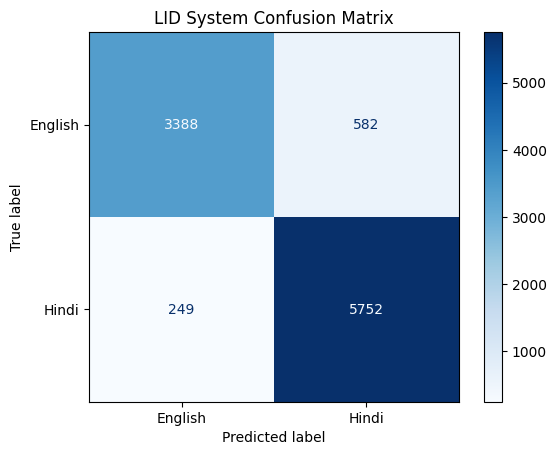

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


class_names = ['English', 'Hindi']


plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay.from_predictions(all_labels, all_preds, display_labels=class_names, cmap='Blues')
plt.title('LID System Confusion Matrix')
plt.show()

In [10]:
test_df = test_dataset.df.iloc[valid_indices].copy()
rev_label_map = {0: "eng", 1: "hin"}
test_df['predicted_label'] = [rev_label_map[p] for p in all_preds]

os.makedirs('/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/xlsr_finetuned_test', exist_ok=True)
output_csv = '/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/xlsr_finetuned_test/xlsr_final_predictions.csv'
test_df.to_csv(output_csv, index=False)
print(f"Test predictions saved to: {output_csv}")

Test predictions saved to: /media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/xlsr_finetuned_test/xlsr_final_predictions.csv



--- Loading BEST Model for Final Testing ---


Testing: 100%|██████████████████████████████| 1247/1247 [01:00<00:00, 20.64it/s]


 FINAL TEST ACCURACY: 91.74% 

Classification Report:
              precision    recall  f1-score   support

     English       0.94      0.85      0.89      3970
       Hindi       0.91      0.96      0.93      6001

    accuracy                           0.92      9971
   macro avg       0.92      0.91      0.91      9971
weighted avg       0.92      0.92      0.92      9971



<Figure size 800x600 with 0 Axes>

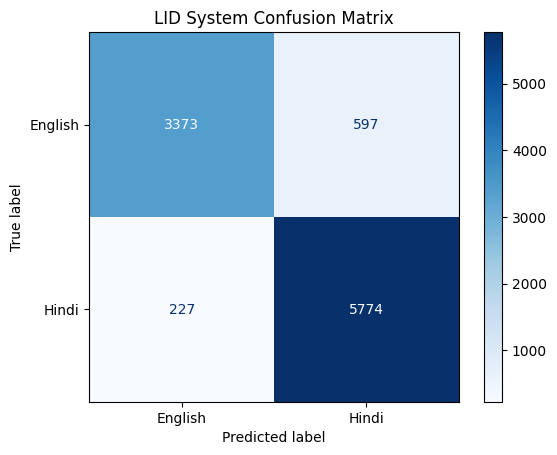

In [15]:
print(f"\n--- Loading BEST Model for Final Testing ---")
model = AutoModelForAudioClassification.from_pretrained(SAVE_DIR, use_safetensors=True).to(device)
model.eval()

all_preds = []
all_labels = []
valid_indices = [] 
current_row_idx = 0

test_loop = tqdm(test_loader, desc="Testing")
with torch.no_grad():
    for batch_audio, batch_labels in test_loop:
        batch_audio = batch_audio.to(device)
        outputs = model(batch_audio)
        probabilities = torch.softmax(outputs.logits, dim=-1)

        hindi_probs = probabilities[:, 1].cpu().numpy()

        predictions = (hindi_probs > 0.43).astype(int)
     
        for i in range(len(batch_labels)):
            if batch_labels[i].item() != -100:
                all_preds.append(predictions[i])
                all_labels.append(batch_labels[i].item())
                valid_indices.append(current_row_idx)
            current_row_idx += 1

final_acc = accuracy_score(all_labels, all_preds)
print(f"\n FINAL TEST ACCURACY: {final_acc * 100:.2f}% \n")
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=["English", "Hindi"]))
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


class_names = ['English', 'Hindi']


plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay.from_predictions(all_labels, all_preds, display_labels=class_names, cmap='Blues')
plt.title('LID System Confusion Matrix')
plt.show()
